In [1]:
# =========================
# master : 가상의 신호를 생성하여 Worker에게 전송하고,
#          Worker로부터 FFT 결과를 받아 처리 시간을 확인
#==========================

In [6]:
# import
import socket        # TCP 통신을 위한 소켓 라이브러리
import numpy as np
import time          # 시간 축정
import matplotlib.pyplot as plt

In [7]:
# 서버 설정
HOST = "localhost"   # 마스터 서버 주소
PORT = 9999          # 통신 포트

In [11]:
# 신호 생성
signal_length = 30000 # 데이터 길이 (심볼개수)

# 정규분포 기반 랜덤 신호 생성
signal = np.random.randn(signal_length).astype(np.float32)

In [13]:
# 표에 한글이 깨지지 않도록 폰트 추가
from matplotlib import font_manager, rc

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

Master : Worker 접속 대기 중...
master : worker 접속됨 - 주소 : ('127.0.0.1', 64684)
master : 신호 전송 시작
master : 신호 전송 완료, 결과 대기 중.....
master : FFT 결과 수신 완료 (길이 : 30000)
[왕복 처리 시간] 0.004084 초


AttributeError: module 'matplotlib.pyplot' has no attribute 'tilte'

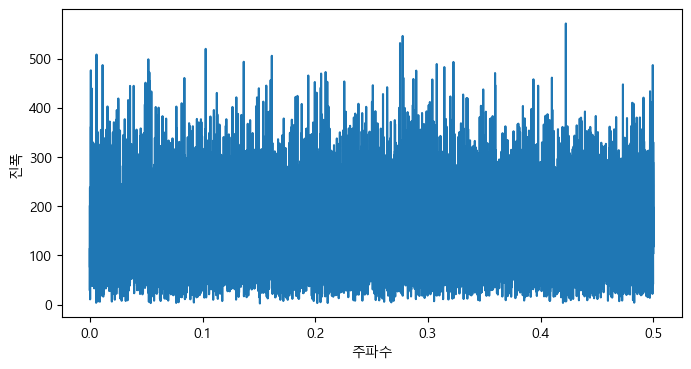

In [14]:
# TCP 서버 시작
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind((HOST, PORT)) # 서버 주소와 포트 연결
    s.listen()        # 클라이언트 접속 대기

    print("Master : Worker 접속 대기 중...")

    conn, addr = s.accept()  # Workere 접속시까지 대기

    with conn:
        print(f"master : worker 접속됨 - 주소 : {addr}")

        start_time = time.time() # 처리 시간 측정 시작
        print("master : 신호 전송 시작")

        conn.sendall(signal.tobytes())  # numpy type -> bytes로 변환 후 전송
        print("master : 신호 전송 완료, 결과 대기 중.....")

        # 데이터 수신
        expected_bytes = signal_length * 4 # float32 -> 4bytes
        received = b""  # 수신 데이터 누적

        # tcp는 데이터가 쪼개져서 들어오기 때문에 반복 수신 처리 필요
        while len(received) < expected_bytes:
            chunk = conn.recv(4096)

            if not chunk:      # 데이터 없으면 연결 종료
                break
            received += chunk  # 데이터 누적

        #데이터 변환
        fft_result = np.frombuffer(received, dtype=np.float32)
        print(f"master : FFT 결과 수신 완료 (길이 : {len(fft_result)})")

        # 처리시간 측정 완료
        end_time = time.time()
        elapsed = end_time - start_time

        print(f"[왕복 처리 시간] {elapsed:.4} 초")

        # 결과 시각화
        # FFT 결과 (FFT는 주파수를 의미함. 한마디로 주파수 결과)
        freqs = np.fft.fftfreq(signal_length, d=1.0)

        plt.figure(figsize=(8,4))

        plt.plot(
            freqs[:signal_length // 2],
            fft_result[:signal_length // 2]
        )

        plt.xlabel('주파수')
        plt.ylabel('진폭')
        plt.tilte('FFT 결과 (master-worker)')

        plt.tight_layout()
        plt.show()

        